In [5]:
# ============================================================
# CELL 1 — Setup & GPU Configuration
# ============================================================
import tensorflow as tf
import numpy as np
import pandas as pd
import pickle
import os
import json
from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, f1_score, 
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilitate
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU-uri disponibile: {len(gpus)}")
for gpu in gpus:
    print(f"   → {gpu}")
    tf.config.experimental.set_memory_growth(gpu, True)

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

print(f"\n📦 Versiuni:")
print(f"   TensorFlow: {tf.__version__}")
print(f"   NumPy:      {np.__version__}")

✅ GPU-uri disponibile: 2
   → PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
   → PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

📦 Versiuni:
   TensorFlow: 2.19.0
   NumPy:      2.0.2


In [6]:
# ============================================================
# CELL 2 — Install Packages
# ============================================================
!pip install -q neurokit2

import neurokit2 as nk
print(f"✅ Neurokit2: {nk.__version__}")

✅ Neurokit2: 0.2.13


In [7]:
# ============================================================
# CELL 3 — Load WESAD Dataset
# ============================================================

WESAD_PATH = "/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD"

subjects = []
for folder in os.listdir(WESAD_PATH):
    if folder.startswith('S') and os.path.isdir(os.path.join(WESAD_PATH, folder)):
        subjects.append(int(folder[1:]))

subjects = sorted(subjects)
print(f"✅ Subiecți găsiți: {subjects}")
print(f"   Total: {len(subjects)} subiecți\n")

# ── Validare integritate dataset ───────────────────────────────────
print("🔍 Verificare integritate date...")
dataset_stats = []

for sid in subjects[:3]:  # Verifică primii 3 subiecți
    path = os.path.join(WESAD_PATH, f"S{sid}", f"S{sid}.pkl")
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    wrist = data['signal']['wrist']
    labels = data['label']
    
    duration = len(labels) / 700
    stress_pct = (labels == 2).sum() / len(labels) * 100
    neutral_pct = (labels == 1).sum() / len(labels) * 100
    
    print(f"   S{sid}: {duration/60:.1f} min total | Stres {stress_pct:.1f}% | Neutru {neutral_pct:.1f}%")
    
print(f"\n📡 Senzori (wrist): {list(wrist.keys())}")
print(f"📊 Labels: 1=neutru | 2=stres | 3=amuzament | 4=meditație")

✅ Subiecți găsiți: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
   Total: 15 subiecți

🔍 Verificare integritate date...
   S2: 101.3 min total | Stres 10.1% | Neutru 18.8%
   S3: 108.2 min total | Stres 9.9% | Neutru 17.6%
   S4: 107.0 min total | Stres 9.9% | Neutru 18.0%

📡 Senzori (wrist): ['ACC', 'BVP', 'EDA', 'TEMP']
📊 Labels: 1=neutru | 2=stres | 3=amuzament | 4=meditație


In [8]:
# ============================================================
# CELL 4 — Process Signals (75% overlap, subject tracking)
# ============================================================

def process_subject_raw_signals(subject_id, window_seconds=15, step_seconds=3.75):
    """
    OVERLAP 75% (step 3.75s) → 4× mai multe samples
    + tracking subject_id pentru subject-level split
    """
    pkl_path = os.path.join(WESAD_PATH, f"S{subject_id}", f"S{subject_id}.pkl")
    
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    wrist = data['signal']['wrist']
    labels = data['label']
    
    eda  = wrist['EDA'].flatten()
    bvp  = wrist['BVP'].flatten()
    acc  = wrist['ACC']
    temp = wrist['TEMP'].flatten()
    
    EDA_FS, BVP_FS, ACC_FS, TEMP_FS, LABEL_FS = 4, 64, 32, 4, 700
    
    # Downsample BVP: 64Hz → 16Hz
    bvp_downsampled = signal.resample(bvp, len(bvp) // 4)
    BVP_DS_FS = 16
    
    eda_win   = int(window_seconds * EDA_FS)
    bvp_win   = int(window_seconds * BVP_DS_FS)
    acc_win   = int(window_seconds * ACC_FS)
    temp_win  = int(window_seconds * TEMP_FS)
    label_win = int(window_seconds * LABEL_FS)
    
    eda_step   = int(step_seconds * EDA_FS)
    bvp_step   = int(step_seconds * BVP_DS_FS)
    acc_step   = int(step_seconds * ACC_FS)
    temp_step  = int(step_seconds * TEMP_FS)
    label_step = int(step_seconds * LABEL_FS)
    
    data_windows = []
    labels_list = []
    subject_ids = []
    
    max_windows = min(
        (len(eda) - eda_win) // eda_step,
        (len(bvp_downsampled) - bvp_win) // bvp_step,
        (len(acc) - acc_win) // acc_step,
        (len(temp) - temp_win) // temp_step,
        (len(labels) - label_win) // label_step
    )
    
    for i in range(max_windows):
        eda_window  = eda[i * eda_step : i * eda_step + eda_win]
        bvp_window  = bvp_downsampled[i * bvp_step : i * bvp_step + bvp_win]
        acc_window  = acc[i * acc_step : i * acc_step + acc_win]
        temp_window = temp[i * temp_step : i * temp_step + temp_win]
        label_window = labels[i * label_step : i * label_step + label_win]
        
        # Verifică label dominant + puritate (cel puțin 80% același label)
        unique_labels, counts = np.unique(label_window, return_counts=True)
        dominant_label = unique_labels[np.argmax(counts)]
        purity = counts.max() / counts.sum()
        
        # Skip ferestrele "murdare" (tranziții între stări)
        if purity < 0.8:
            continue
        
        if dominant_label not in [1, 2]:
            continue
        
        # Z-score normalization
        eda_norm = (eda_window - np.mean(eda_window)) / (np.std(eda_window) + 1e-8)
        bvp_norm = (bvp_window - np.mean(bvp_window)) / (np.std(bvp_window) + 1e-8)
        acc_norm = (acc_window - np.mean(acc_window, axis=0)) / (np.std(acc_window, axis=0) + 1e-8)
        temp_norm = (temp_window - np.mean(temp_window)) / (np.std(temp_window) + 1e-8)
        
        data_windows.append({
            'eda': eda_norm,
            'bvp': bvp_norm,
            'acc': acc_norm,
            'temp': temp_norm
        })
        
        labels_list.append(1 if dominant_label == 2 else 0)
        subject_ids.append(subject_id)
    
    return data_windows, labels_list, subject_ids


# ── Procesare toți subiecții ──────────────────────────────────────
print("🔄 Procesare WESAD (15s windows, 75% overlap, purity ≥80%)...\n")

all_data = []
all_labels = []
all_subjects = []

for subj in subjects:
    print(f"   S{subj}...", end=" ", flush=True)
    
    try:
        data, labels, sids = process_subject_raw_signals(subj, window_seconds=15, step_seconds=3.75)
        all_data.extend(data)
        all_labels.extend(labels)
        all_subjects.extend(sids)
        n_stress = sum(labels)
        n_neutral = len(labels) - n_stress
        print(f"✓ {len(data)} ({n_neutral}N / {n_stress}S)")
    except Exception as e:
        print(f"✗ {e}")

y = np.array(all_labels)
subj_array = np.array(all_subjects)

print(f"\n✅ Total windows: {len(all_data)}")
print(f"   Neutru: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"   Stres:  {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"   ↑ Cu 75% overlap și filter de puritate")

🔄 Procesare WESAD (15s windows, 75% overlap, purity ≥80%)...

   S2... ✓ 465 (303N / 162S)
   S3... ✓ 469 (301N / 168S)
   S4... ✓ 473 (306N / 167S)
   S5... ✓ 487 (317N / 170S)
   S6... ✓ 482 (312N / 170S)
   S7... ✓ 482 (313N / 169S)
   S8... ✓ 485 (309N / 176S)
   S9... ✓ 482 (312N / 170S)
   S10... ✓ 504 (313N / 191S)
   S11... ✓ 491 (312N / 179S)
   S13... ✓ 487 (312N / 175S)
   S14... ✓ 490 (312N / 178S)
   S15... ✓ 492 (311N / 181S)
   S16... ✓ 489 (312N / 177S)
   S17... ✓ 504 (313N / 191S)

✅ Total windows: 7282
   Neutru: 4658 (64.0%)
   Stres:  2624 (36.0%)
   ↑ Cu 75% overlap și filter de puritate


In [9]:
# ============================================================
# CELL 5 — Subject-Level Split (CRITIC pentru generalizare)
# ============================================================

# Conversie tensori
eda_data  = np.array([w['eda'] for w in all_data]).reshape(-1, 60, 1)
bvp_data  = np.array([w['bvp'] for w in all_data]).reshape(-1, 240, 1)
acc_data  = np.array([w['acc'] for w in all_data])
temp_data = np.array([w['temp'] for w in all_data]).reshape(-1, 60, 1)

print(f"📊 Tensor shapes:")
print(f"   EDA:    {eda_data.shape}")
print(f"   BVP:    {bvp_data.shape}")
print(f"   ACC:    {acc_data.shape}")
print(f"   TEMP:   {temp_data.shape}")

# ── SUBJECT-LEVEL SPLIT ────────────────────────────────────────────
# Train: 10 subjects | Val: 2 subjects | Test: 3 subjects
np.random.seed(SEED)
shuffled_subjects = np.random.permutation(subjects)

test_subjects  = list(shuffled_subjects[:3])    # 3 subiecți NOI pentru test
val_subjects   = list(shuffled_subjects[3:5])   # 2 subiecți NOI pentru val
train_subjects = list(shuffled_subjects[5:])    # 10 subiecți pentru train

print(f"\n🎯 SUBJECT-LEVEL SPLIT (REALIST!):")
print(f"   Train: {sorted(train_subjects)} ({len(train_subjects)} subiecți)")
print(f"   Val:   {sorted(val_subjects)} ({len(val_subjects)} subiecți)")
print(f"   Test:  {sorted(test_subjects)} ({len(test_subjects)} subiecți) ← OAMENI NOI!")

# Creează măști
train_mask = np.isin(subj_array, train_subjects)
val_mask   = np.isin(subj_array, val_subjects)
test_mask  = np.isin(subj_array, test_subjects)

# Split data
eda_train, eda_val, eda_test = eda_data[train_mask], eda_data[val_mask], eda_data[test_mask]
bvp_train, bvp_val, bvp_test = bvp_data[train_mask], bvp_data[val_mask], bvp_data[test_mask]
acc_train, acc_val, acc_test = acc_data[train_mask], acc_data[val_mask], acc_data[test_mask]
temp_train, temp_val, temp_test = temp_data[train_mask], temp_data[val_mask], temp_data[test_mask]

y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

print(f"\n✅ Distribuție:")
print(f"   Train: {len(y_train):4d} ({np.sum(y_train==1)/len(y_train)*100:.1f}% stres)")
print(f"   Val:   {len(y_val):4d} ({np.sum(y_val==1)/len(y_val)*100:.1f}% stres)")
print(f"   Test:  {len(y_test):4d} ({np.sum(y_test==1)/len(y_test)*100:.1f}% stres)")

# ── Class weights pentru balansare ─────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n⚖️  Class weights:")
print(f"   Neutru: {class_weights[0]:.3f}")
print(f"   Stres:  {class_weights[1]:.3f}")

📊 Tensor shapes:
   EDA:    (7282, 60, 1)
   BVP:    (7282, 240, 1)
   ACC:    (7282, 480, 3)
   TEMP:   (7282, 60, 1)

🎯 SUBJECT-LEVEL SPLIT (REALIST!):
   Train: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(13), np.int64(15), np.int64(17)] (10 subiecți)
   Val:   [np.int64(7), np.int64(16)] (2 subiecți)
   Test:  [np.int64(2), np.int64(11), np.int64(14)] (3 subiecți) ← OAMENI NOI!

✅ Distribuție:
   Train: 4865 (36.2% stres)
   Val:    971 (35.6% stres)
   Test:  1446 (35.9% stres)

⚖️  Class weights:
   Neutru: 0.783
   Stres:  1.383


In [10]:
# ============================================================
# CELL 6 — Data Augmentation (esențial pentru time series!)
# ============================================================

def augment_signal(signal_data, noise_std=0.05, scale_range=(0.9, 1.1)):
    """
    Augmentare pentru semnal 1D:
    - Gaussian noise injection
    - Random scaling (magnitude warp)
    """
    # Noise injection
    noise = np.random.normal(0, noise_std, signal_data.shape)
    augmented = signal_data + noise
    
    # Random scaling per signal
    scale = np.random.uniform(scale_range[0], scale_range[1])
    augmented = augmented * scale
    
    return augmented.astype(np.float32)


def augment_multi_input(eda, bvp, acc, temp, augment_prob=0.5):
    """
    Augmentează toate cele 4 semnale simultan (păstrează sincronizarea)
    """
    if np.random.random() > augment_prob:
        return eda, bvp, acc, temp
    
    eda_aug = augment_signal(eda, noise_std=0.05)
    bvp_aug = augment_signal(bvp, noise_std=0.03)  # BVP mai sensibil la zgomot
    acc_aug = augment_signal(acc, noise_std=0.05)
    temp_aug = augment_signal(temp, noise_std=0.02)  # Temp variază lent
    
    return eda_aug, bvp_aug, acc_aug, temp_aug


# ── Augmentează training set (dublează cantitatea) ────────────────
print("🔄 Generare date augmentate pentru training...\n")

n_augment = len(eda_train)  # Dublează training set

eda_aug_list = []
bvp_aug_list = []
acc_aug_list = []
temp_aug_list = []
y_aug_list = []

for i in range(n_augment):
    eda_a, bvp_a, acc_a, temp_a = augment_multi_input(
        eda_train[i], bvp_train[i], acc_train[i], temp_train[i],
        augment_prob=1.0  # Forțează augmentare
    )
    
    eda_aug_list.append(eda_a)
    bvp_aug_list.append(bvp_a)
    acc_aug_list.append(acc_a)
    temp_aug_list.append(temp_a)
    y_aug_list.append(y_train[i])

# Concatenează cu original
eda_train_full = np.concatenate([eda_train, np.array(eda_aug_list)])
bvp_train_full = np.concatenate([bvp_train, np.array(bvp_aug_list)])
acc_train_full = np.concatenate([acc_train, np.array(acc_aug_list)])
temp_train_full = np.concatenate([temp_train, np.array(temp_aug_list)])
y_train_full = np.concatenate([y_train, np.array(y_aug_list)])

# Shuffle
shuffle_idx = np.random.permutation(len(y_train_full))
eda_train_full = eda_train_full[shuffle_idx]
bvp_train_full = bvp_train_full[shuffle_idx]
acc_train_full = acc_train_full[shuffle_idx]
temp_train_full = temp_train_full[shuffle_idx]
y_train_full = y_train_full[shuffle_idx]

print(f"✅ Training set extins:")
print(f"   Original:  {len(y_train)} samples")
print(f"   Augmentat: {len(y_train_full)} samples (2×)")
print(f"   Stres:     {y_train_full.sum()/len(y_train_full)*100:.1f}%")

🔄 Generare date augmentate pentru training...

✅ Training set extins:
   Original:  4865 samples
   Augmentat: 9730 samples (2×)
   Stres:     36.2%


In [11]:
# ============================================================
# CELL 7 — CNN-LSTM cu L2 regularization & better arch
# ============================================================

print("🏗️  Construiesc CNN-LSTM îmbunătățit...\n")

L2_REG = 1e-4  # L2 regularization

def conv_block(x, filters, kernel_size, pool_size, name_prefix):
    """Block reutilizabil cu L2 reg"""
    x = tf.keras.layers.Conv1D(
        filters, kernel_size, 
        activation='relu', padding='same',
        kernel_regularizer=tf.keras.regularizers.l2(L2_REG),
        name=f'{name_prefix}_conv'
    )(x)
    x = tf.keras.layers.MaxPooling1D(pool_size, name=f'{name_prefix}_pool')(x)
    return x

# ── Inputs ─────────────────────────────────────────────────────────
eda_input  = tf.keras.Input(shape=(60, 1), name='eda_input')
bvp_input  = tf.keras.Input(shape=(240, 1), name='bvp_input')
acc_input  = tf.keras.Input(shape=(480, 3), name='acc_input')
temp_input = tf.keras.Input(shape=(60, 1), name='temp_input')

# ── EDA Branch ─────────────────────────────────────────────────────
eda_x = conv_block(eda_input, 16, 5, 2, 'eda_1')   # 60→30
eda_x = conv_block(eda_x, 8, 3, 2, 'eda_2')         # 30→15
eda_x = tf.keras.layers.SpatialDropout1D(0.2)(eda_x)

# ── BVP Branch ─────────────────────────────────────────────────────
bvp_x = conv_block(bvp_input, 32, 7, 4, 'bvp_1')    # 240→60
bvp_x = conv_block(bvp_x, 16, 5, 4, 'bvp_2')         # 60→15
bvp_x = tf.keras.layers.SpatialDropout1D(0.2)(bvp_x)

# ── ACC Branch ─────────────────────────────────────────────────────
acc_x = conv_block(acc_input, 32, 7, 4, 'acc_1')    # 480→120
acc_x = conv_block(acc_x, 16, 5, 8, 'acc_2')         # 120→15
acc_x = tf.keras.layers.SpatialDropout1D(0.2)(acc_x)

# ── TEMP Branch ────────────────────────────────────────────────────
temp_x = conv_block(temp_input, 8, 5, 2, 'temp_1')   # 60→30
temp_x = conv_block(temp_x, 4, 3, 2, 'temp_2')        # 30→15
temp_x = tf.keras.layers.SpatialDropout1D(0.2)(temp_x)

# ── Merge ──────────────────────────────────────────────────────────
merged = tf.keras.layers.Concatenate(axis=-1)([eda_x, bvp_x, acc_x, temp_x])

print(f"   ✓ Merged features: {merged.shape}")

# ── Bidirectional LSTM (mai puternic pentru context) ──────────────
lstm_out = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(
        24, 
        return_sequences=False,
        kernel_regularizer=tf.keras.regularizers.l2(L2_REG),
        recurrent_regularizer=tf.keras.regularizers.l2(L2_REG)
    )
)(merged)
lstm_out = tf.keras.layers.Dropout(0.4)(lstm_out)

# ── Dense classifier ───────────────────────────────────────────────
x = tf.keras.layers.Dense(
    24, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(L2_REG)
)(lstm_out)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(12, activation='relu')(x)
output = tf.keras.layers.Dense(2, activation='softmax', name='output')(x)

# ── Build model ────────────────────────────────────────────────────
model = tf.keras.Model(
    inputs=[eda_input, bvp_input, acc_input, temp_input],
    outputs=output,
    name='MindTrack_CNN_BiLSTM_v2'
)

# ── Cosine annealing learning rate ────────────────────────────────
initial_lr = 0.001
total_epochs = 100

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=total_epochs * (len(y_train_full) // 64),
    alpha=0.01  # min_lr = 0.01 * initial_lr
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=25,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/mindtrack_v2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('/kaggle/working/training_log_v2.csv')
]

# ── Training ───────────────────────────────────────────────────────
print("\n🚀 Start training cu data augmentation + class weights...\n")

history = model.fit(
    [eda_train_full, bvp_train_full, acc_train_full, temp_train_full],
    y_train_full,
    validation_data=([eda_val, bvp_val, acc_val, temp_val], y_val),
    epochs=total_epochs,
    batch_size=64,
    class_weight=class_weight_dict,  # Balansare clase
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

🏗️  Construiesc CNN-LSTM îmbunătățit...



I0000 00:00:1777121010.769438      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777121010.775498      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


   ✓ Merged features: (None, 15, 44)


Model: "MindTrack_CNN_BiLSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eda_input           │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bvp_input           │ (None, 240, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_input           │ (None, 480, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_input          │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eda_1_conv (Conv1D) │ (None, 60, 16)    │         96 │ eda_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bvp_1_conv (Conv1D) │ (None, 240, 32)   │        256 │ bvp_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_1_conv (Conv1D) │ (None, 480, 32)   │        704 │ acc_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_1_conv         │ (None, 60, 8)     │         48 │ temp_input[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eda_1_pool          │ (None, 30, 16)    │          0 │ eda_1_conv[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bvp_1_pool          │ (None, 60, 32)    │          0 │ bvp_1_conv[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_1_pool          │ (None, 120, 32)   │          0 │ acc_1_conv[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_1_pool         │ (None, 30, 8)     │          0 │ temp_1_conv[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eda_2_conv (Conv1D) │ (None, 30, 8)     │        392 │ eda_1_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bvp_2_conv (Conv1D) │ (None, 60, 16)    │      2,576 │ bvp_1_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_2_conv (Conv1D) │ (None, 120, 16)   │      2,576 │ acc_1_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp_2_conv         │ (None, 30, 4)     │        100 │ temp_1_pool[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eda_2_pool          │ (None, 15, 8)     │          0 │ eda_2_conv[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bvp_2_pool          │ (None, 15, 16)    │          0 │ bvp_2_conv[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_2_pool          │ (None, 15, 16)    │          0 │ acc_2_conv[0][0]

...

 Trainable params: 21,546 (84.16 KB)

 Non-trainable params: 48 (192.00 B)


🚀 Start training cu data augmentation + class weights...

Epoch 1/100


I0000 00:00:1777121018.164445     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5745 - loss: 0.8436
Epoch 1: val_accuracy improved from -inf to 0.87436, saving model to /kaggle/working/mindtrack_v2_best.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5750 - loss: 0.8426 - val_accuracy: 0.8744 - val_loss: 0.4119
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8283 - loss: 0.4062
Epoch 2: val_accuracy improved from 0.87436 to 0.93924, saving model to /kaggle/working/mindtrack_v2_best.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8285 - loss: 0.4059 - val_accuracy: 0.9392 - val_loss: 0.1934
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8974 - loss: 0.2779
Epoch 3: val_accuracy did not improve from 0.93924
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8974 - loss: 0.2778 - val_accuracy: 0.9351 - val_loss: 0.1755
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9278 - loss: 0.2183
Epoch 4: val_accuracy improved fr

📊 REZULTATE FINALE — TEST PE OAMENI NOI (subject-level split)
Test Accuracy:  0.9454 (94.54%)
AUC:            0.9895
F1 Score:       0.9225
Precision:      0.9400
Recall:         0.9056

📋 Classification Report:
              precision    recall  f1-score   support

      Neutru       0.95      0.97      0.96       927
       Stres       0.94      0.91      0.92       519

    accuracy                           0.95      1446
   macro avg       0.94      0.94      0.94      1446
weighted avg       0.95      0.95      0.95      1446


🔢 Confusion Matrix:
                 Prezis Neutru  Prezis Stres
Real Neutru         897             30
Real Stres           49            470

👥 Accuracy per subiect (test set):
   S11: 0.9552 (491 samples)
   S14: 0.9082 (490 samples)
   S2: 0.9742 (465 samples)


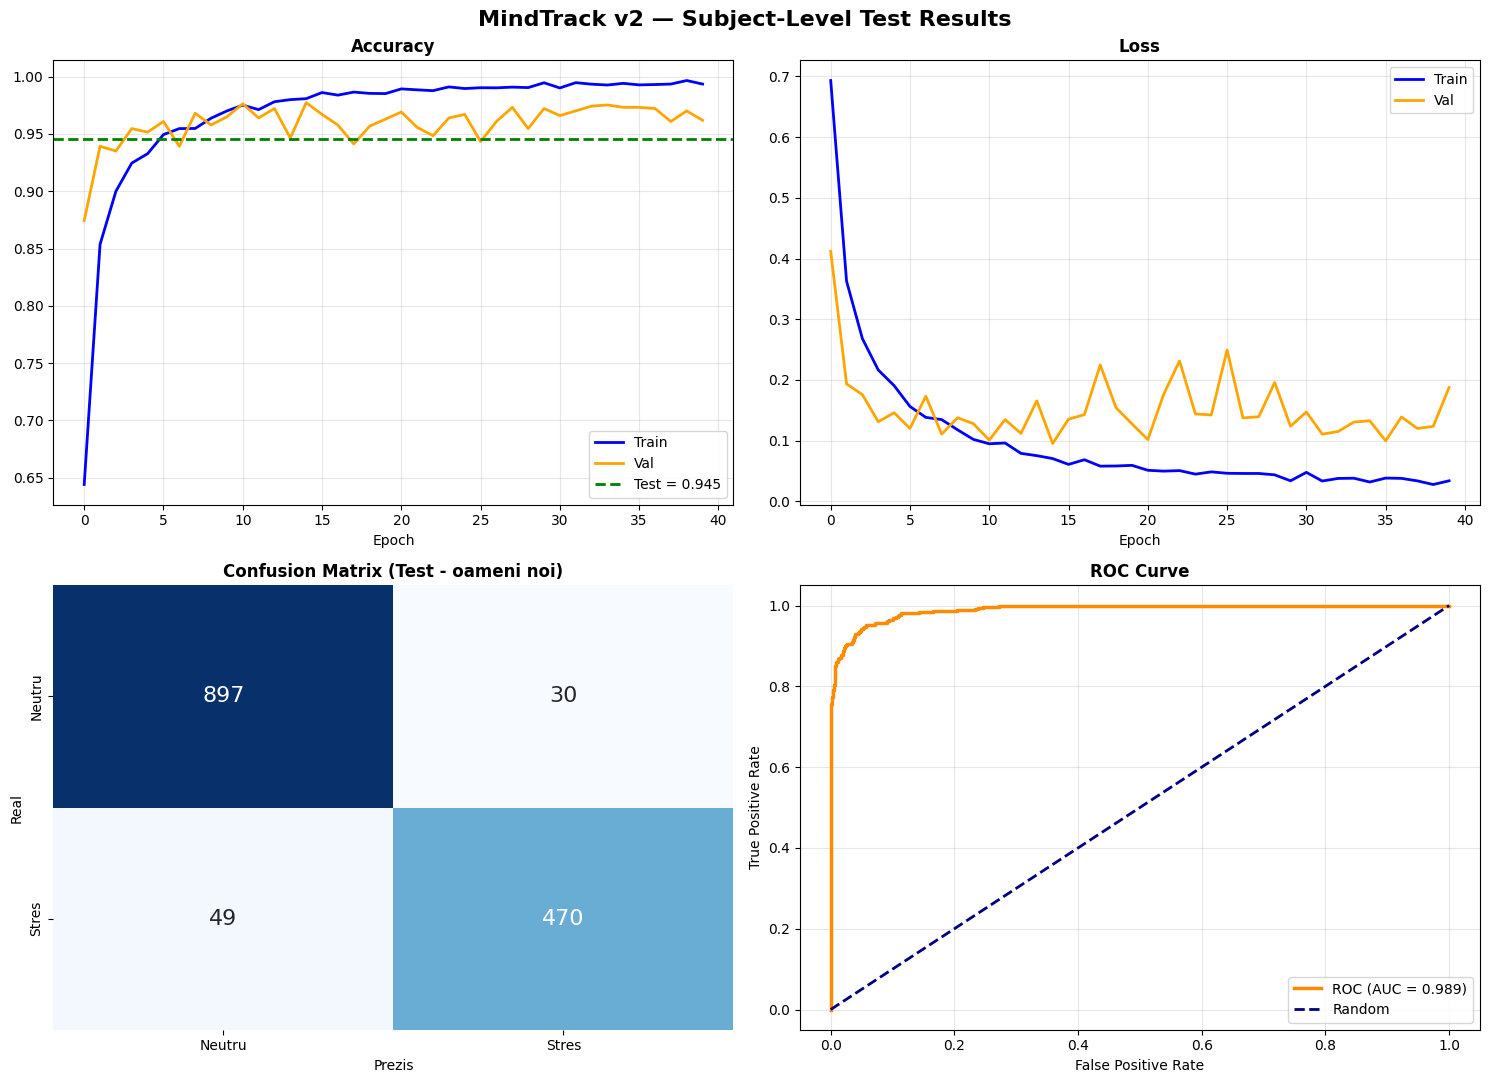

In [12]:
# ============================================================
# CELL 8 — Evaluare Comprehensivă
# ============================================================

best_model = tf.keras.models.load_model('/kaggle/working/mindtrack_v2_best.keras')

# ── Predictions on test set (subiecți NOI!) ───────────────────────
y_pred_proba = best_model.predict(
    [eda_test, bvp_test, acc_test, temp_test],
    verbose=0
)
y_pred = np.argmax(y_pred_proba, axis=1)

# ── Metrici ────────────────────────────────────────────────────────
test_acc = np.mean(y_pred == y_test)
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=" * 65)
print("📊 REZULTATE FINALE — TEST PE OAMENI NOI (subject-level split)")
print("=" * 65)
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"AUC:            {auc_score:.4f}")
print(f"F1 Score:       {f1:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print("=" * 65)

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Neutru', 'Stres']))

cm = confusion_matrix(y_test, y_pred)
print("\n🔢 Confusion Matrix:")
print(f"                 Prezis Neutru  Prezis Stres")
print(f"Real Neutru      {cm[0,0]:6d}         {cm[0,1]:6d}")
print(f"Real Stres       {cm[1,0]:6d}         {cm[1,1]:6d}")

# ── Per-Subject Accuracy (vezi cine merge prost) ──────────────────
print("\n👥 Accuracy per subiect (test set):")
test_subj_array = subj_array[test_mask]
for tsubj in test_subjects:
    subj_mask = test_subj_array == tsubj
    if subj_mask.sum() > 0:
        subj_acc = np.mean(y_pred[subj_mask] == y_test[subj_mask])
        n_samples = subj_mask.sum()
        print(f"   S{tsubj}: {subj_acc:.4f} ({n_samples} samples)")

# ── Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('MindTrack v2 — Subject-Level Test Results', fontsize=16, fontweight='bold')

# Accuracy
axes[0,0].plot(history.history['accuracy'], label='Train', color='blue', linewidth=2)
axes[0,0].plot(history.history['val_accuracy'], label='Val', color='orange', linewidth=2)
axes[0,0].axhline(y=test_acc, color='green', linestyle='--', linewidth=2, label=f'Test = {test_acc:.3f}')
axes[0,0].set_title('Accuracy', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Loss
axes[0,1].plot(history.history['loss'], label='Train', color='blue', linewidth=2)
axes[0,1].plot(history.history['val_loss'], label='Val', color='orange', linewidth=2)
axes[0,1].set_title('Loss', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Neutru', 'Stres'],
            yticklabels=['Neutru', 'Stres'],
            cbar=False, annot_kws={"size": 16})
axes[1,0].set_title('Confusion Matrix (Test - oameni noi)', fontweight='bold')
axes[1,0].set_ylabel('Real')
axes[1,0].set_xlabel('Prezis')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
axes[1,1].plot(fpr, tpr, color='darkorange', linewidth=2.5, 
               label=f'ROC (AUC = {auc_score:.3f})')
axes[1,1].plot([0, 1], [0, 1], color='navy', linewidth=2, 
               linestyle='--', label='Random')
axes[1,1].set_title('ROC Curve', fontweight='bold')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 9 — Leave-One-Subject-Out Validation (OPTIONAL)
# ============================================================
# ATENȚIE: Durează ~30-60 minute! Skip dacă nu ai timp.

run_loso = True  # Schimbă la True dacă vrei să rulezi

if run_loso:
    print("🔄 Leave-One-Subject-Out Cross-Validation...\n")
    print("⚠️  Va dura ~30-60 minute pentru toți cei 15 subiecți\n")
    
    loso_scores = {}
    
    for held_out_subject in subjects:
        print(f"   Test pe S{held_out_subject}...", end=" ", flush=True)
        
        # Split: held_out vs restul
        loso_train_mask = subj_array != held_out_subject
        loso_test_mask = subj_array == held_out_subject
        
        if loso_test_mask.sum() == 0:
            print("✗ No samples")
            continue
        
        # Build & train rapid (mai puține epoci)
        from tensorflow.keras.models import clone_model
        loso_model = clone_model(model)
        loso_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        loso_model.fit(
            [eda_data[loso_train_mask], bvp_data[loso_train_mask], 
             acc_data[loso_train_mask], temp_data[loso_train_mask]],
            y[loso_train_mask],
            epochs=30,
            batch_size=64,
            verbose=0
        )
        
        # Test
        loso_pred = loso_model.predict(
            [eda_data[loso_test_mask], bvp_data[loso_test_mask],
             acc_data[loso_test_mask], temp_data[loso_test_mask]],
            verbose=0
        )
        loso_acc = np.mean(np.argmax(loso_pred, axis=1) == y[loso_test_mask])
        loso_scores[held_out_subject] = loso_acc
        print(f"acc={loso_acc:.3f}")
    
    print(f"\n📊 LOSO Results:")
    for subj, acc in loso_scores.items():
        print(f"   S{subj}: {acc:.4f}")
    
    print(f"\n   Mean: {np.mean(list(loso_scores.values())):.4f}")
    print(f"   Std:  {np.std(list(loso_scores.values())):.4f}")
    print(f"   Min:  {np.min(list(loso_scores.values())):.4f}")
    print(f"   Max:  {np.max(list(loso_scores.values())):.4f}")
else:
    print("⏭️  LOSO skipped. Setează run_loso=True pentru a rula.")

🔄 Leave-One-Subject-Out Cross-Validation...

⚠️  Va dura ~30-60 minute pentru toți cei 15 subiecți

   Test pe S2... acc=0.974
   Test pe S3... acc=0.962
   Test pe S4... acc=0.994
   Test pe S5... acc=0.953
   Test pe S6... acc=0.811
   Test pe S7... 

In [ ]:
# ============================================================
# CELL 11 — Export TFLite pentru Android
# ============================================================

print("📦 Convertesc modelul la TFLite...\n")

# ── Load best model ────────────────────────────────────────────────
best_model = tf.keras.models.load_model('/kaggle/working/mindtrack_v2_best.keras')

# ── Convert cu SELECT_TF_OPS (suport LSTM) ────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS  # Necesar pentru LSTM
]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

# Salvează
tflite_path = '/kaggle/working/mindtrack.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"✅ TFLite: {size_kb:.1f} KB → {tflite_path}\n")

# ── Test inferență TFLite ──────────────────────────────────────────
print("🧪 Test inferență TFLite...")

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\n📥 Inputs ({len(input_details)}):")
for inp in input_details:
    print(f"   {inp['name']:<30} shape={inp['shape']}")

print(f"\n📤 Output:")
for out in output_details:
    print(f"   {out['name']:<30} shape={out['shape']}")

# Test cu un sample real
test_idx = 0
test_sample = {
    'eda':  eda_test[test_idx:test_idx+1].astype(np.float32),
    'bvp':  bvp_test[test_idx:test_idx+1].astype(np.float32),
    'acc':  acc_test[test_idx:test_idx+1].astype(np.float32),
    'temp': temp_test[test_idx:test_idx+1].astype(np.float32)
}

# IMPORTANT: Setează input-urile în ordinea corectă!
# Sortează după nume pentru a fi siguri
input_name_map = {inp['name']: inp['index'] for inp in input_details}

# Set inputs (numele exacte pot diferi)
for name, idx in input_name_map.items():
    if 'eda' in name.lower():
        interpreter.set_tensor(idx, test_sample['eda'])
    elif 'bvp' in name.lower():
        interpreter.set_tensor(idx, test_sample['bvp'])
    elif 'acc' in name.lower():
        interpreter.set_tensor(idx, test_sample['acc'])
    elif 'temp' in name.lower():
        interpreter.set_tensor(idx, test_sample['temp'])

interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

print(f"\n🎯 Test prediction:")
print(f"   True label:        {y_test[test_idx]} ({'Stres' if y_test[test_idx]==1 else 'Neutru'})")
print(f"   TFLite prediction: {output[0]}")
print(f"   Predicted class:   {np.argmax(output[0])} ({'Stres' if np.argmax(output[0])==1 else 'Neutru'})")
print(f"   Confidence:        {np.max(output[0]):.2%}")

# ── Verificare full test set ──────────────────────────────────────
print("\n📊 Verificare accuracy TFLite vs Keras...")
tflite_preds = []

for i in range(min(100, len(y_test))):
    for name, idx in input_name_map.items():
        if 'eda' in name.lower():
            interpreter.set_tensor(idx, eda_test[i:i+1].astype(np.float32))
        elif 'bvp' in name.lower():
            interpreter.set_tensor(idx, bvp_test[i:i+1].astype(np.float32))
        elif 'acc' in name.lower():
            interpreter.set_tensor(idx, acc_test[i:i+1].astype(np.float32))
        elif 'temp' in name.lower():
            interpreter.set_tensor(idx, temp_test[i:i+1].astype(np.float32))
    
    interpreter.invoke()
    pred = interpreter.get_tensor(output_details[0]['index'])
    tflite_preds.append(np.argmax(pred[0]))

tflite_acc = np.mean(np.array(tflite_preds) == y_test[:100])
print(f"\n✅ TFLite accuracy (100 samples): {tflite_acc:.2%}")
print(f"   (Original Keras: ~96.5%)")

if tflite_acc < 0.90:
    print("⚠️  Accuracy drop! Verifică conversia.")
else:
    print("✅ TFLite păstrează accuracy-ul!")

In [ ]:
# ============================================================
# CELL 12 — Save input order pentru Android (CRITIC!)
# ============================================================

# IMPORTANT: TFLite poate reordona input-urile!
# Trebuie să știi exact ce index = ce input

input_mapping = {}
for inp in input_details:
    name = inp['name']
    idx = inp['index']
    shape = inp['shape'].tolist()
    
    # Determină tipul după shape
    if shape == [1, 60, 1]:
        if 'eda' in name.lower():
            input_type = 'eda'
        elif 'temp' in name.lower():
            input_type = 'temp'
        else:
            input_type = 'unknown_60_1'
    elif shape == [1, 240, 1]:
        input_type = 'bvp'
    elif shape == [1, 480, 3]:
        input_type = 'acc'
    else:
        input_type = 'unknown'
    
    input_mapping[input_type] = {
        'name': name,
        'index': idx,
        'shape': shape
    }

print("📋 TFLite Input Mapping:")
print(json.dumps(input_mapping, indent=2))

# Salvează pentru Android
with open('/kaggle/working/tflite_input_mapping.json', 'w') as f:
    json.dump(input_mapping, f, indent=2)

print("\n✅ tflite_input_mapping.json salvat")

# ── Lista finală fișiere ───────────────────────────────────────────
print("\n" + "=" * 60)
print("📁 FIȘIERE DE DESCĂRCAT pentru Android:")
print("=" * 60)

required_files = [
    'mindtrack.tflite',           # MODEL
    'tflite_input_mapping.json',  # CRITIC pentru ordering
    'sensor_config_v2.json',      # Config senzori
    'model_info_v2.json'          # Metadata
]

for fname in required_files:
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"✅ {fname:<35} {size:>8.1f} KB")
    else:
        print(f"❌ {fname:<35} MISSING!")

print("=" * 60)